In [2]:
import torch
from torch import nn
import requests
import zipfile
from pathlib import Path

data_path = Path('data/')
image_path = data_path / 'pizza_steak_sushi'

if image_path.is_dir():
    print(f"{image_path} already exists!")
else:
    print(f"Does not exist creatin one.....")
    image_path.mkdir(parents=True,exist_ok=True)

    with open(data_path / "pizza_steak_sushi.zip",'wb') as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("downloading required images")
        f.write(request.content)

    with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip','r') as zip_ref:
        print('unzipping images')
        zip_ref.extractall(image_path)

data\pizza_steak_sushi already exists!


In [3]:
import os
def walk_through_directory(dir_path):

    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

walk_through_directory(image_path)

There are 2 directories and 0 images in data\pizza_steak_sushi
There are 3 directories and 0 images in data\pizza_steak_sushi\test
There are 0 directories and 25 images in data\pizza_steak_sushi\test\pizza
There are 0 directories and 19 images in data\pizza_steak_sushi\test\steak
There are 0 directories and 31 images in data\pizza_steak_sushi\test\sushi
There are 3 directories and 0 images in data\pizza_steak_sushi\train
There are 0 directories and 78 images in data\pizza_steak_sushi\train\pizza
There are 0 directories and 75 images in data\pizza_steak_sushi\train\steak
There are 0 directories and 72 images in data\pizza_steak_sushi\train\sushi


In [4]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

Random image path: data\pizza_steak_sushi\test\sushi\2394442.jpg
Image class: sushi
Image height: 408
Image width: 512


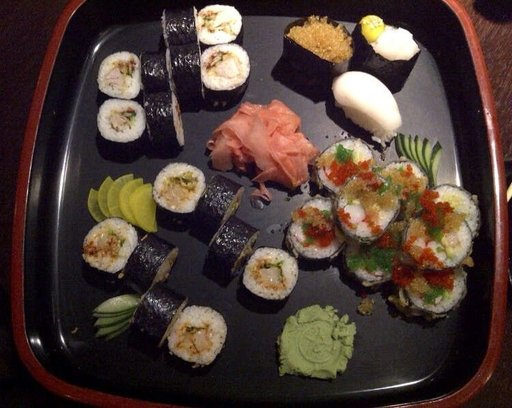

In [5]:
import random
from PIL import Image

random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(407.5), np.float64(-0.5))

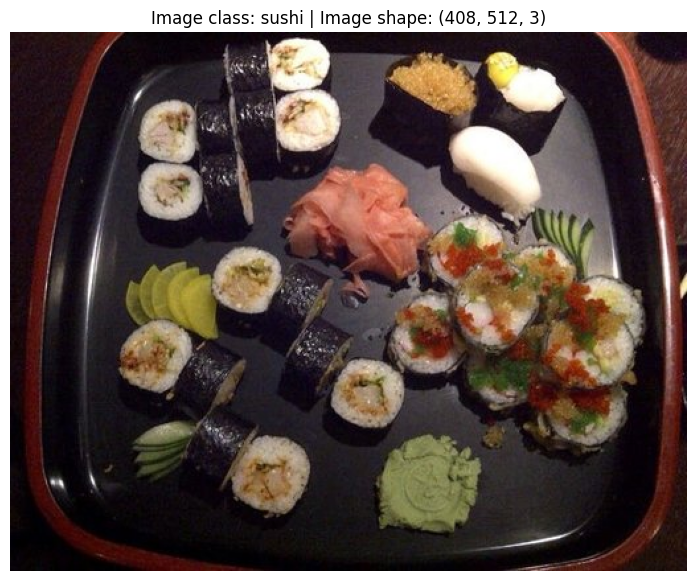

In [6]:
import matplotlib.pyplot as plt
import numpy as np

image_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(image_as_array)
plt.title(f"Image class: {image_class} | Image shape: {image_as_array.shape}")
plt.axis(False)

In [7]:
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

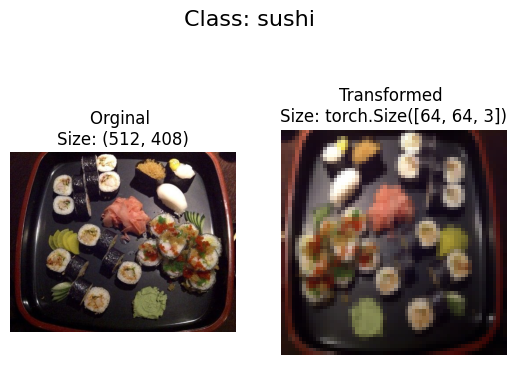

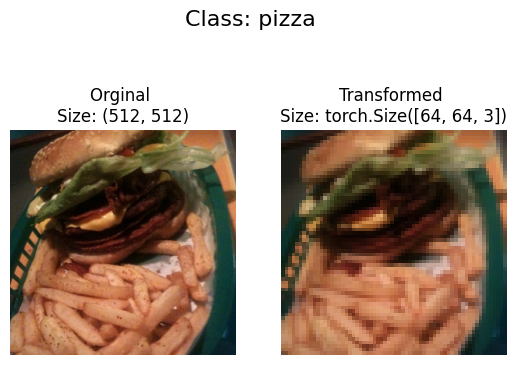

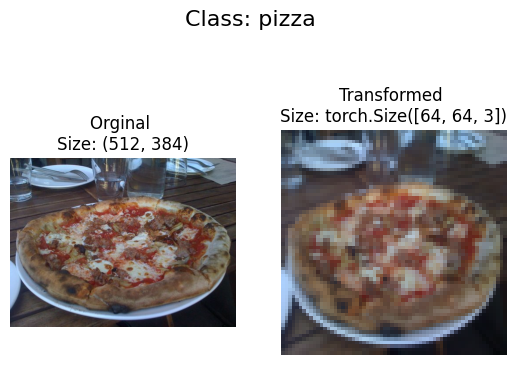

In [8]:
def plot_transformed_images(image_paths,transform,n=3,seed=42):
    random.seed(seed)
    random_image_paths = random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title(f"Orginal \nSize: {f.size}")
            ax[0].axis('off')

            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis('off')

            fig.suptitle(f"Class: {image_path.parent.stem}",fontsize=16)

plot_transformed_images(image_path_list,transform=data_transform,n=3)

In [9]:
train_data = datasets.ImageFolder(root=train_dir,transform=data_transform,target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,transform=data_transform)

print(f"Train Data: {train_data}\nTest Data: {test_data}")

Train Data: Dataset ImageFolder
    Number of datapoints: 225
    Root location: data\pizza_steak_sushi\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test Data: Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [10]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names,class_dict,len(train_data),len(test_data)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2}, 225, 75)

In [11]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'pizza')

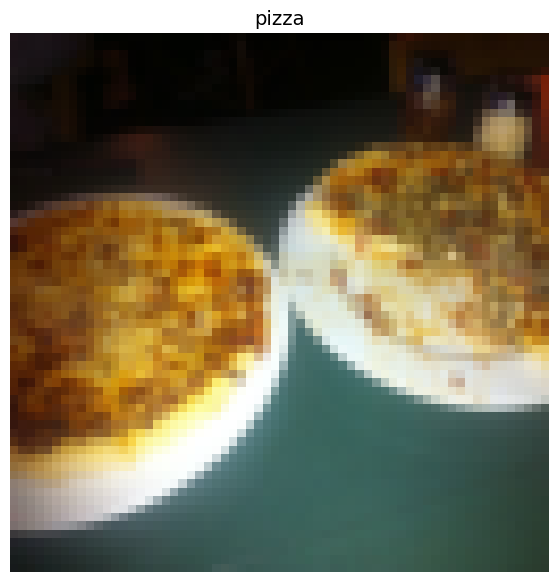

In [12]:
img_permute = img.permute(1,2,0)

print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

plt.figure(figsize=(10,7))
plt.imshow(img.permute(1,2,0))
plt.axis('off')
plt.title(class_names[label],fontsize=14)

In [13]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1,
                              num_workers=1,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x27832a98830>,
 <torch.utils.data.dataloader.DataLoader at 0x27834e564b0>)

In [14]:
img, label = next(iter(train_dataloader))

print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


In [15]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [16]:
def find_classes(directory:str) -> Tuple[List[str], Dict[str,int]]:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    if not classes:
        raise FileNotFoundError(f"No file")
    
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes,class_to_idx

find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [17]:
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):

    def __init__(self,targ_dir:str,transform=None) -> None:
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)

    def load_image(self,index:int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self,index:int) -> Tuple[torch.Tensor,int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img),class_idx
        else:
            return img,class_idx


In [18]:
train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [19]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,transform=train_transform)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,transform=test_transform)

train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x27834f27e60>,
 <__main__.ImageFolderCustom at 0x27834f8b230>)

In [20]:
len(train_data_custom), len(test_data_custom)
train_data_custom.classes
train_data_custom.class_to_idx

# Check for equality amongst our custom Dataset and ImageFolder Dataset
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True
True


In [21]:
def display_random_images(dataset:torch.utils.data.dataset.Dataset, classes:List[str]=None,n:int = 10, display_shape:bool = True, seed:int = None):
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")
    
    if seed:
        random.seed(seed)

    random_sample_idx = random.sample(range(len(dataset)),k=n)
    plt.figure(figsize=(16,8))

    for i, targ_sample in enumerate(random_sample_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        targ_image_adjust = targ_image.permute(1,2,0)

        plt.subplot(1,n,i+1)
        plt.imshow(targ_image_adjust)
        plt.axis('off')
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nShape: {targ_image_adjust.shape}"
        plt.title(title)

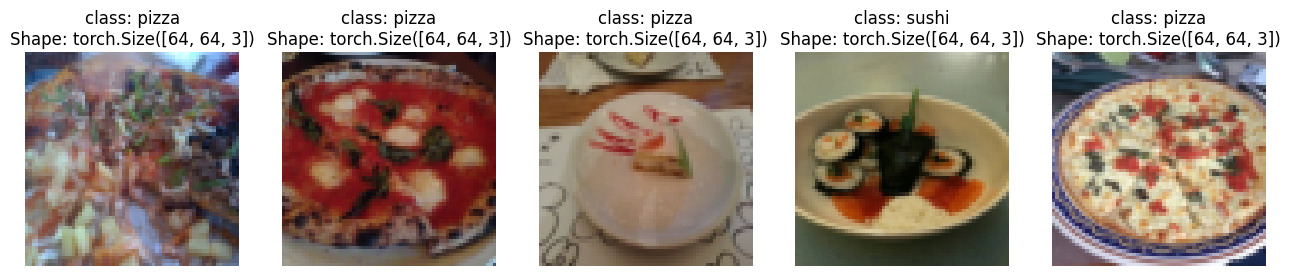

In [22]:
display_random_images(dataset = train_data,
                    n = 5,
                    classes = class_names,
                    seed = None
                    )

For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


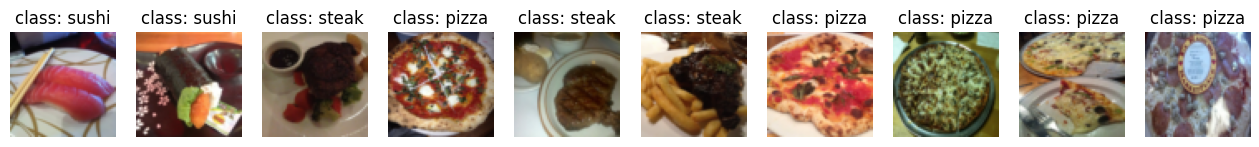

In [23]:
display_random_images(dataset = train_data_custom,
                        n = 12,
                        classes = class_names,
                        seed = None)

In [24]:
from torch.utils.data import DataLoader

train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                        batch_size = 1,
                                        num_workers = 0,
                                        shuffle = True)

test_dataloader_custom = DataLoader(dataset = test_data_custom,
                                        batch_size = 1,
                                        num_workers = 0,
                                        shuffle = False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x27834e54890>,
 <torch.utils.data.dataloader.DataLoader at 0x278370d03e0>)

In [25]:
img_custom, label_custom = next(iter(train_dataloader_custom))

print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


In [26]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

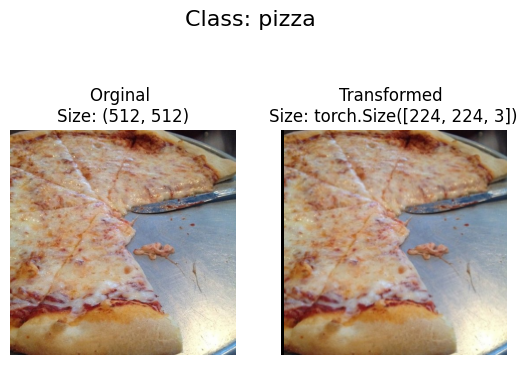

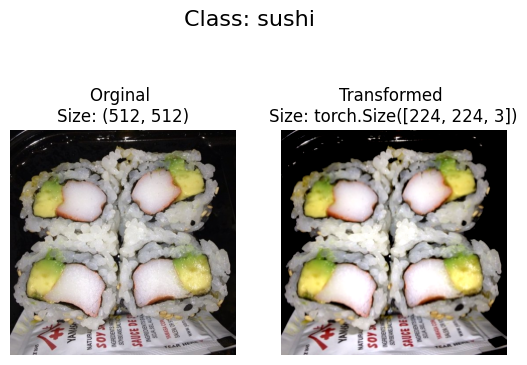

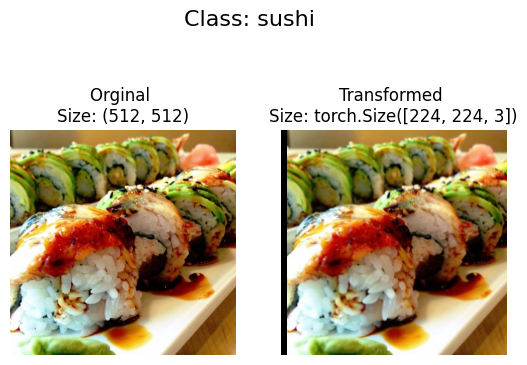

In [27]:
image_path_list = list(image_path.glob("*/*/*.jpg"))

plot_transformed_images(
    image_paths = image_path_list,
    transform = train_transforms,
    n = 3,
    seed = None
)

In [28]:
simple_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [29]:
train_data_simple = datasets.ImageFolder(root=train_dir,transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir,transform=simple_transform)

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

train_dataloader_simple = DataLoader(
    train_data_simple,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS
)

test_dataloader_simple = DataLoader(
    test_data_simple,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS
)

train_dataloader_simple, test_dataloader_simple

Creating DataLoader's with batch size 32 and 8 workers.


(<torch.utils.data.dataloader.DataLoader at 0x27837134080>,
 <torch.utils.data.dataloader.DataLoader at 0x27837135220>)

In [30]:
class TinyVGG(nn.Module):

    def __init__(self,input_shape: int, hidden_units: int, output_shape: int) -> int:
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(
                in_channels = input_shape,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels = hidden_units,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size = 2,
                stride = 2
            )
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(
                in_channels = hidden_units,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels = hidden_units,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size = 2,
                stride = 2
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features = hidden_units*16*16,
                out_features = output_shape
            )
        )

    def forward(self,x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)

model0 = TinyVGG(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(train_data.classes)
)

model0

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=3, bias=True)
  )
)

In [31]:
img_batch, label_batch = next(iter(train_dataloader_simple))

img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

model0.eval()
with torch.inference_mode():
    pred = model0(img_single)
    
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[0.0079, 0.0172, 0.0029]])

Output prediction probabilities:
tensor([[0.3328, 0.3360, 0.3312]])

Output prediction label:
tensor([1])

Actual label:
2


In [32]:
import torchinfo
    
from torchinfo import summary
summary(model0, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [33]:
def train_step(model:torch.nn.Module, dataloader:torch.utils.data.DataLoader, loss_fn:torch.nn.Module, optimizer:torch.optim.Optimizer):
    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X,y) in enumerate(dataloader):

        y_preds = model(X)

        loss = loss_fn(y_preds,y)

        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_preds, dim=1),dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_preds)

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc
        

In [34]:
def test_step(model:torch.nn.Module, dataloader:torch.utils.data.DataLoader, loss_fn:torch.nn.Module):
    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):

            test_preds = model(X)

            testing_loss = loss_fn(test_preds,y)

            test_loss += testing_loss.item()

            test_pred_labels = torch.argmax(torch.softmax(test_preds, dim=1),dim=1)
            test_acc += (test_pred_labels == y).sum().item()/len(test_preds)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc

In [35]:
from tqdm.auto import tqdm

def train(model:torch.nn.Module, train_dataloader:torch.utils.data.DataLoader, test_dataloader:torch.utils.data.DataLoader, loss_fn:torch.nn.Module, optimizer:torch.optim.Optimizer, epochs: int = 5):

    results = {
                "train_loss" : [],
                "train_acc" : [],
                "test_loss" : [],
                "test_acc" : []
            }

    for epoch in tqdm(range(epochs)):
                train_loss, train_acc = train_step(model=model,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer)
                test_loss, test_acc = test_step(model=model,dataloader=test_dataloader,loss_fn=loss_fn)

                print(
                f"Epoch: {epoch+1} | "
                f"train_loss: {train_loss:.4f} | "
                f"train_acc: {train_acc:.4f} | "
                f"test_loss: {test_loss:.4f} | "
                f"test_acc: {test_acc:.4f}"
                )

                results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
                results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
                results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
                results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results

c:\Users\abhit\OneDrive\Documents\Programming\neuron\tf-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model0.parameters(),lr=0.001)

from timeit import default_timer as timer

start_time = timer()

model0_results = train(model=model0, train_dataloader=train_dataloader_simple, test_dataloader=test_dataloader_simple, optimizer=optimizer, loss_fn=loss_fn, epochs=NUM_EPOCHS)

end_time = timer()

print(f"Total training time: {end_time-start_time:.3f} seconds")


 20%|██        | 1/5 [00:23<01:33, 23.40s/it]

Epoch: 1 | train_loss: 1.1051 | train_acc: 0.2500 | test_loss: 1.0927 | test_acc: 0.2604


 40%|████      | 2/5 [00:42<01:03, 21.01s/it]

Epoch: 2 | train_loss: 1.0808 | train_acc: 0.4258 | test_loss: 1.1287 | test_acc: 0.2604


 60%|██████    | 3/5 [01:00<00:39, 19.57s/it]

Epoch: 3 | train_loss: 1.0829 | train_acc: 0.4258 | test_loss: 1.1266 | test_acc: 0.2604


 80%|████████  | 4/5 [01:21<00:20, 20.17s/it]

Epoch: 4 | train_loss: 1.0743 | train_acc: 0.3047 | test_loss: 1.1247 | test_acc: 0.3021


100%|██████████| 5/5 [01:37<00:00, 19.58s/it]

Epoch: 5 | train_loss: 1.0515 | train_acc: 0.4375 | test_loss: 1.0449 | test_acc: 0.4034
Total training time: 97.884 seconds


In [37]:
model0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

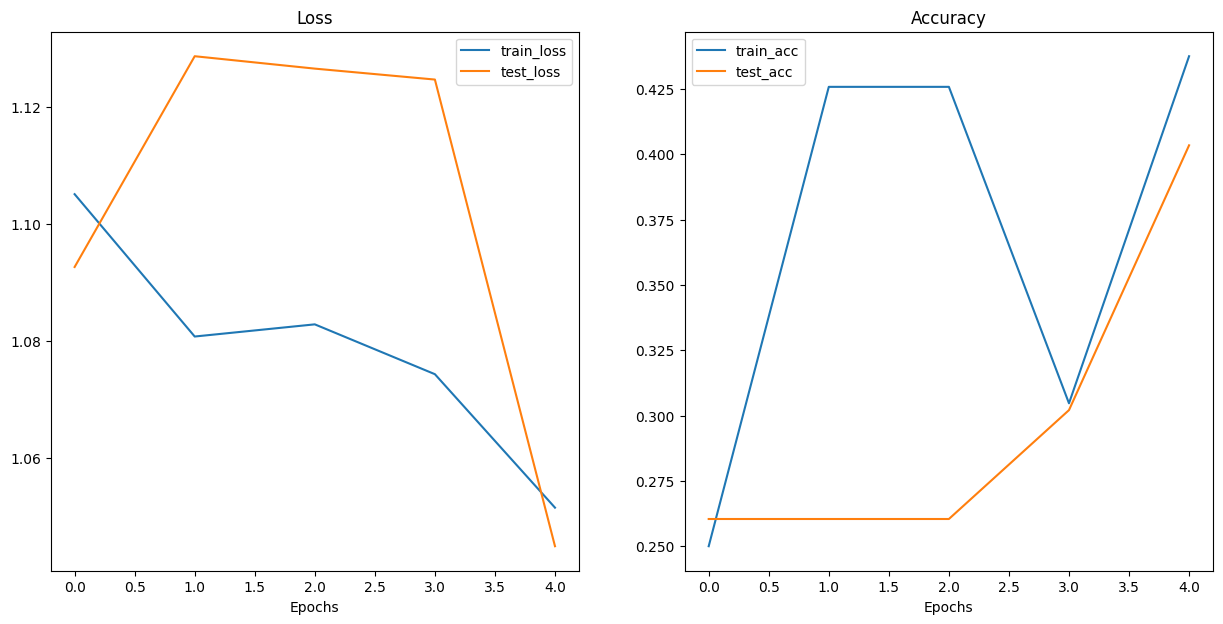

In [38]:
def plot_loss_curves(results: Dict[str,List[float]]):
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15,7))

    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, accuracy, label='train_acc')
    plt.plot(epochs, test_accuracy, label='test_acc')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

plot_loss_curves(model0_results)

In [39]:
train_transform_trivial_augment = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [40]:
train_data_augment = datasets.ImageFolder(train_dir, transform=train_transform_trivial_augment)
test_data_simple = datasets.ImageFolder(test_dir, transform=test_transform)

train_data_augment, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [41]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)

train_dataloader_augmented = DataLoader(train_data_augment, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(test_data_simple, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

train_dataloader_augmented, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x27837350fe0>,
 <torch.utils.data.dataloader.DataLoader at 0x278372840b0>)

In [42]:
torch.manual_seed(42)

model1 = TinyVGG(
    input_shape=3,
    hidden_units=32,
    output_shape=len(train_data_augment.classes)
)

model1

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=3, bias=True)
  )
)

In [43]:
torch.manual_seed(42)

NUM_EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model1.parameters(),lr=0.001)

from timeit import default_timer as timer

start_time = timer()

model1_results = train(model=model1, train_dataloader=train_dataloader_augmented, test_dataloader=test_dataloader_simple, optimizer=optimizer, loss_fn=loss_fn, epochs=NUM_EPOCHS)

end_time = timer()

print(f"Total training time: {end_time-start_time:.3f} seconds")

 20%|██        | 1/5 [00:18<01:12, 18.17s/it]

Epoch: 1 | train_loss: 1.1061 | train_acc: 0.2500 | test_loss: 1.1001 | test_acc: 0.2604


 40%|████      | 2/5 [00:33<00:49, 16.66s/it]

Epoch: 2 | train_loss: 1.0824 | train_acc: 0.4258 | test_loss: 1.1330 | test_acc: 0.2604


 60%|██████    | 3/5 [00:51<00:34, 17.10s/it]

Epoch: 3 | train_loss: 1.0869 | train_acc: 0.4258 | test_loss: 1.1325 | test_acc: 0.2604


 80%|████████  | 4/5 [01:13<00:19, 19.01s/it]

Epoch: 4 | train_loss: 1.0807 | train_acc: 0.3164 | test_loss: 1.1054 | test_acc: 0.3731


100%|██████████| 5/5 [01:32<00:00, 18.57s/it]

Epoch: 5 | train_loss: 1.0022 | train_acc: 0.5859 | test_loss: 1.1116 | test_acc: 0.3125
Total training time: 92.863 seconds


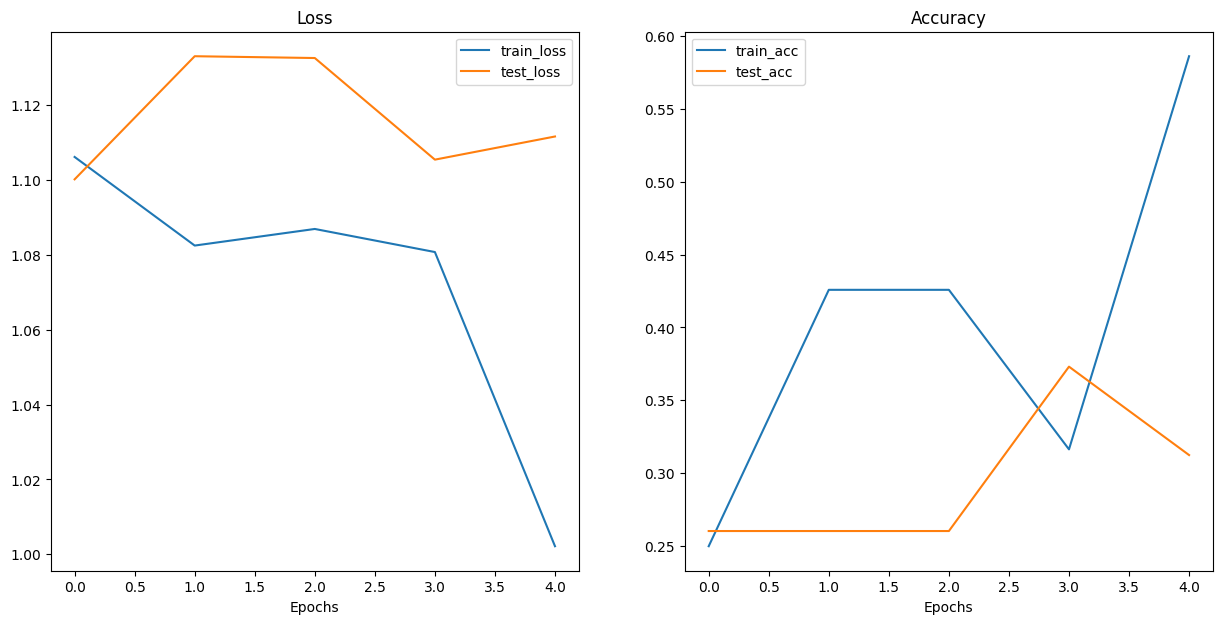

In [44]:
plot_loss_curves(model1_results)

In [45]:
import pandas as pd
model_0_df = pd.DataFrame(model0_results)
model_1_df = pd.DataFrame(model1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.105130,0.250000,1.092667,0.260417
1,1.080770,0.425781,1.128742,0.260417
2,1.082852,0.425781,1.126620,0.260417
3,1.074323,0.304688,1.124748,0.302083
4,1.051481,0.437500,1.044880,0.403409


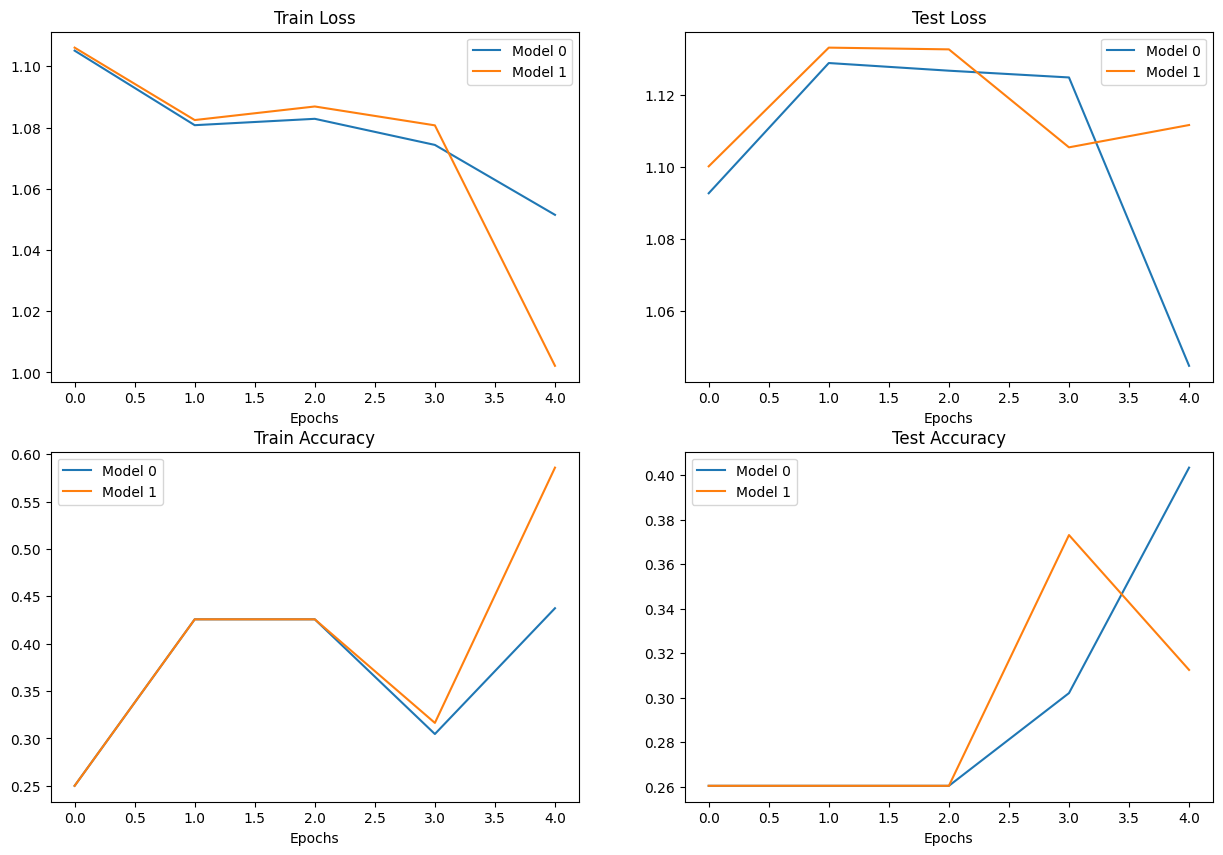

In [46]:
# Setup a plot 
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend()

In [47]:
import torchvision
custom_image_path = data_path / "3837522.jpg"

custom_image_transform = transforms.Compose([
    transforms.Resize((64,64)),
])

In [48]:
def pred_and_plot_img(model:torch.nn.Module, image_path:str, class_names:List[str]=None, transform=None):

    target_img = torchvision.io.read_image(str(image_path)).float()

    target_img = target_img/255

    if transform:
        target_img = transform(target_img)

    model.eval()

    with torch.inference_mode():
        target_img = target_img.unsqueeze(dim=0)
        target_img_pred = model(target_img)
        target_img_label = torch.argmax(torch.softmax(target_img_pred,dim=1),dim=1)

        plt.imshow(target_img.squeeze().permute(1,2,0))
        
        if class_names:
            title = f"Pred: {class_names[target_img_label]}"
        else:
            title = f"Pred: {target_img_label}"

        plt.title(title)
        plt.axis(False)

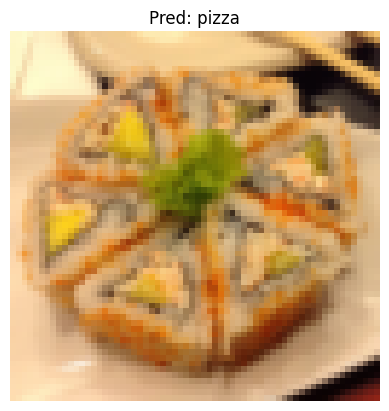

In [53]:
pred_and_plot_img(model=model0, image_path=custom_image_path, class_names=class_names, transform=custom_image_transform)